(200, 2) (200, 1)


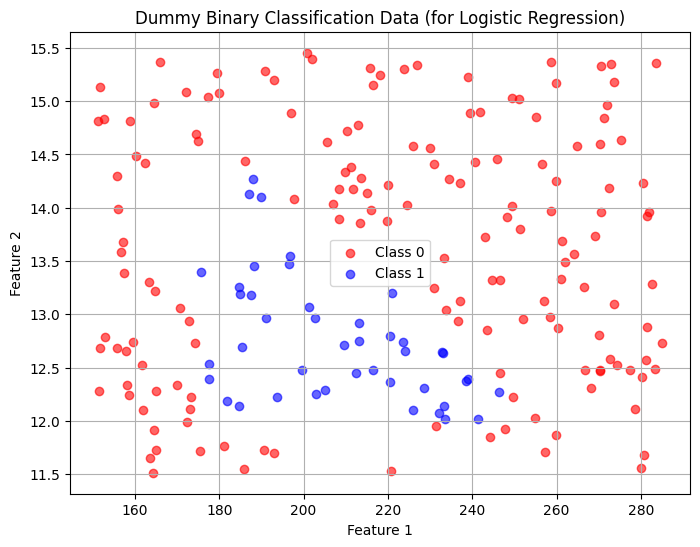

In [290]:
import numpy as np
from matplotlib import pyplot as plt

def load_coffee_data():
    """ Creates a coffee roasting data set.
        roasting duration: 12-15 minutes is best
        temperature range: 175-260C is best
    """
    rng = np.random.default_rng(2)
    X = rng.random(400).reshape(-1,2)
    X[:,1] = X[:,1] * 4 + 11.5          # 12-15 min is best
    X[:,0] = X[:,0] * (285-150) + 150  # 350-500 F (175-260 C) is best
    Y = np.zeros(len(X))
    
    i=0
    for t,d in X:
        y = -3/(260-175)*t + 21
        if (t > 175 and t < 260 and d > 12 and d < 15 and d<=y ):
            Y[i] = 1
        else:
            Y[i] = 0
        i += 1

    return (X, Y.reshape(-1,1))

X,y = load_coffee_data()
print(X.shape, y.shape)

# Plot
plt.figure(figsize=(8, 6))
plt.scatter(X[y.flatten() == 0][:, 0], X[y.flatten() == 0][:, 1], color="red", label="Class 0", alpha=0.6)
plt.scatter(X[y.flatten() == 1][:, 0], X[y.flatten() == 1][:, 1], color="blue", label="Class 1", alpha=0.6)
plt.title("Dummy Binary Classification Data (for Logistic Regression)")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.grid(True)
plt.show()


In [291]:
X = (X - np.mean(X, axis=0)) / np.std(X, axis=0)

In [292]:
layers = [6,2,1]
learning_rate = 0.5
W=[]
b=[]
inputs=X.shape[1]

m = X.shape[0]

for L in range(len(layers)):
    if L>0:
        inputs=layers[L-1]
    w = np.random.rand(layers[L], inputs) * 0.1
    W.append(w)
    b_=np.zeros((layers[L],1))
    b.append(b_)
cost_history = []
for epoch in range(10000):
    Z=[]
    A_=X.T
    A=[]
    def sigmoid(z_):
        return 1/(1+np.exp(-z_))
    def der_sigmoid(z):
        return sigmoid(z)*(1-sigmoid(z))
    for i in range(len(layers)):
        z = W[i]@A_+b[i]
        A_ = sigmoid(z)
        Z.append(z)
        A.append(A_)

    cost = - (1 / m) * np.sum(y * np.log(A[-1].T) + (1 - y) * np.log(1 - A[-1].T))
    cost_history.append(cost)
        
    Dw=[]
    Db=[]
    for i in range (len(layers)-1,-1,-1):
        if (i == (len(layers)-1)):
            delta = A[i] - y.T
        else:
            delta = W[i+1].T@delta*(der_sigmoid(Z[i]))
        if i!=0:
            dw = (delta@(A[i-1]).T)/m
        else:
            dw = (delta@X)/m
        Dw.append(dw)
        db = np.sum(delta, axis=1, keepdims=True) / m
        Db.append(db)
    Dw=Dw[::-1]
    Db=Db[::-1]
    for j in range(len(layers)):
         W[j] = W[j]- learning_rate*Dw[j]
         b[j] = b[j]- learning_rate*Db[j]


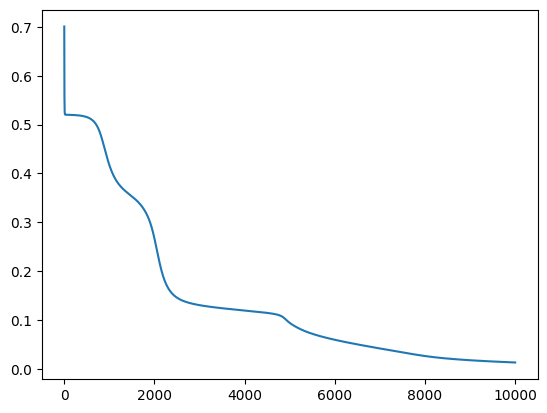

In [293]:
plt.plot(cost_history)

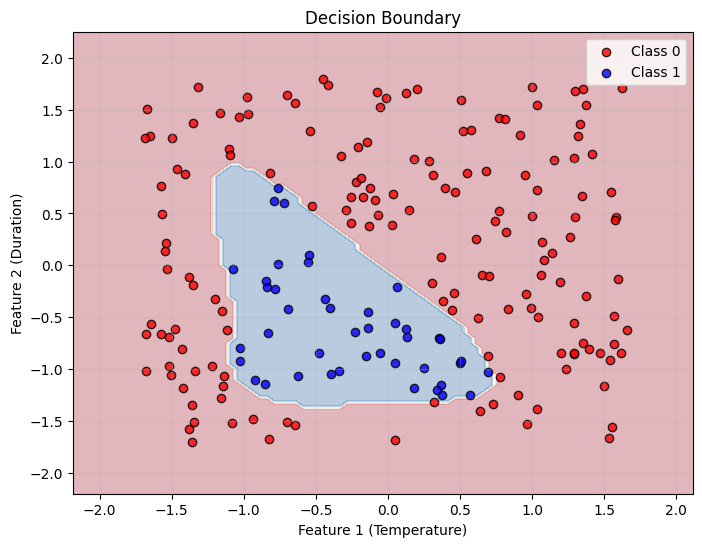

In [303]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Forward pass helper for the grid
def predict(X_grid, W, b):
    def sigmoid(z_):
        return 1 / (1 + np.exp(-z_))
    
    A_ = X_grid.T
    for i in range(len(W)):
        A_ = sigmoid(W[i] @ A_ + b[i])
    return (A_ > 0.5).astype(int).T 

# 2. Setup the meshgrid based on your data ranges
x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.05),
                     np.arange(y_min, y_max, 0.05))

# 3. Get predictions for every point on the grid
grid_points = np.c_[xx.ravel(), yy.ravel()]
Z_grid = predict(grid_points, W, b).reshape(xx.shape)

# 4. Plot everything
plt.figure(figsize=(8, 6))
plt.contourf(xx, yy, Z_grid, alpha=0.3, cmap='RdBu')

plt.scatter(X[y.flatten() == 0][:, 0], X[y.flatten() == 0][:, 1], 
            color="red", label="Class 0", edgecolors='k', alpha=0.8)
plt.scatter(X[y.flatten() == 1][:, 0], X[y.flatten() == 1][:, 1], 
            color="blue", label="Class 1", edgecolors='k', alpha=0.8)

plt.title("Decision Boundary")
plt.xlabel("Feature 1 (Temperature)")
plt.ylabel("Feature 2 (Duration)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()